<a href="https://colab.research.google.com/github/nika19du/AI-for-Developers-summer-2026-/blob/main/The_Supervisor(Planners%26Workers).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## За този pattern е характерно:
- имаме един node, който разбира цялостно какво трябва да бъде свършено, само че този node не върши никаква работа, а само и единствено делегира към специализирани worker nodes

In [1]:
!pip install -q langgraph

In [29]:
import operator
import time

from IPython.display import Image
from enum import Enum
from google.colab import userdata
from langchain.agents import AgentState
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, SystemMessage
from langchain_core.runnables import RunnablePassthrough
from langgraph.checkpoint.base import BaseCheckpointSaver
from langchain_core.runnables import Runnable, RunnableConfig
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph.state import CompiledStateGraph
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langgraph.types import Runnable, Send
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from pathlib import Path
from pydantic import BaseModel, Field, SecretStr
from typing import Annotated, List, Literal, TypedDict

def print_conversation(conversation: List[BaseMessage]):
    for message in conversation:
        message.pretty_print()


def display_graph(runnable: Runnable, output_png: Path) -> None:
    graph = runnable.get_graph()

    with output_png.open(mode = "wb") as file:
        file.write(graph.draw_mermaid_png())

    display(Image(output_png, format = "png"))


def explore_state_history(compiled_state_graph: CompiledStateGraph, config: RunnableConfig):
    state_history = list(compiled_state_graph.get_state_history(config))

    for snapshot in reversed(state_history):
        print(f"Step: {snapshot.metadata['step']}")
        print("Current state:")
        print(snapshot.values)
        print(f"Next: {snapshot.next}")
        print()

In [4]:
class Team(Enum):
    BACK_END = "BE"
    FRONT_END = "FE"
    DEVOPS = "DOps"

class Task(TypedDict):
    team: Team
    title: str

class TaskAssignment(TypedDict):
    task_id: str
    task: Task

def merge_tasks(current: dict[str, Task], new: dict[str, Task]):
    return { **current, **new }

class SystemState(TypedDict):
    user_story: int
    tasks: Annotated[dict[str, Task], merge_tasks]
    finished: Annotated[set[str], operator.or_]


Send типа идва от langgraph, и можем да го използваме за да възложим паралелното изъплнение на няколко задачи от следващите nodo-ве

```
Send("back_end_team", {"task_id": task_id, "task": tasks[task_id]}))
```

FЕ има два свободни слота и получи две задачи, а BE само една но въпреки това имаме паралелно изпълнение на нодовете, работят едновременно - спестяваме време и токени - всяка една задача се изпълнява в свой собствен изолиран контекст

In [13]:
def delegate(state: SystemState):
    tasks = state.get('tasks', {})
    finished = state.get('finished', set())

    free_slots = { Team.BACK_END: 1, Team.FRONT_END: 2, Team.DEVOPS: 1 }
    task_to_assign = {Team.BACK_END: [], Team.FRONT_END: [], Team.DEVOPS: []}

    for task_id, task in tasks.items():
        if task_id in finished or free_slots[task['team']] == 0:
            continue

        free_slots[task['team']] -= 1
        task_to_assign[task['team']].append(task_id)

    result = []
    for task_id in task_to_assign[Team.BACK_END]:
        result.append(Send("back_end_team", {"task_id": task_id, "task": tasks[task_id]}))

    for task_id in task_to_assign[Team.FRONT_END]:
        result.append(Send("front_end_team", {"task_id": task_id, "task": tasks[task_id]}))

    # Note: Assign DevOps tasks only after back-end and front-end teams have finished.
    if not result:
        for task_id in task_to_assign[Team.DEVOPS]:
            result.append(Send("dev_ops_team", {"task_id": task_id, "task": tasks[task_id]}))

    if result:
        return result
    return END

In [15]:
def supervisor(state: SystemState): # superviser ensurva че има задачи които могат да бъдат разпределени към worker nodes
    user_story = state.get('user_story')

    return {
        "tasks": {
            f"{user_story}-be1": {'team': Team.BACK_END, 'title':f"[{user_story}] Main back-end development"},
            f"{user_story}-be2": {'team': Team.BACK_END, 'title':f"[{user_story}] Write integrarion tests"},
            f"{user_story}-be3": {'team': Team.BACK_END, 'title':f"[{user_story}] PR Corrections"},
            f"{user_story}-fe1": {'team': Team.FRONT_END, 'title':f"[{user_story}] Main front-end development"},
            f"{user_story}-fe2": {'team': Team.FRONT_END, 'title':f"[{user_story}] Improve UI and UX"},
            f"{user_story}-dops": {'team': Team.DEVOPS, 'title':f"[{user_story}] Deploy to staging"},
        }
    }


def create_worker_node(expertise: str, wait_seconds: int):
    def worker(task_assignment: TaskAssignment):
        print(f"I am an expert in {expertise} and I will start working over a new task:\n{task_assignment['task']['title']}")

        time.sleep(wait_seconds)
        print(f"Finished task \"{task_assignment}\".")

        return { "finished": {task_assignment['task_id']} }

    return worker

In [22]:
builder = StateGraph(SystemState)

builder.add_node('supervisor', supervisor)
builder.add_node('front_end_team', create_worker_node("front-end development", 1))
builder.add_node('back_end_team', create_worker_node("back-end development", 3))
builder.add_node('dev_ops_team', create_worker_node("DevOps", 5))

builder.add_edge(START, 'supervisor')
builder.add_conditional_edges('supervisor', delegate, ['front_end_team','back_end_team','dev_ops_team', END])
builder.add_edge('front_end_team', 'supervisor')
builder.add_edge('back_end_team', 'supervisor')
builder.add_edge('dev_ops_team', 'supervisor')

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer = checkpointer)

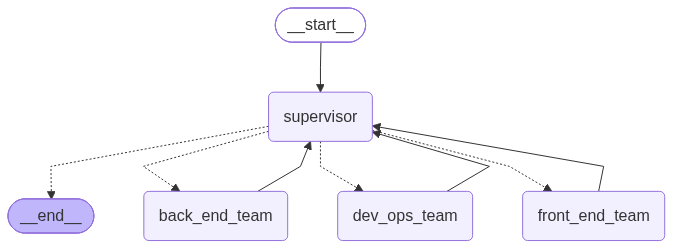

In [23]:
display_graph(graph, Path('/content/graph.png'))

In [24]:
thread1_config = {"configurable": {"thread_id":"thread_1"}}

final_state = graph.invoke(input = {"user_story": 2154}, config = thread1_config)

I am an expert in back-end development and I will start working over a new task:
[2154] Main back-end development
I am an expert in front-end development and I will start working over a new task:
[2154] Improve UI and UX
I am an expert in front-end development and I will start working over a new task:
[2154] Main front-end development
Finished task "{'task_id': '2154-fe2', 'task': {'team': <Team.FRONT_END: 'FE'>, 'title': '[2154] Improve UI and UX'}}".Finished task "{'task_id': '2154-fe1', 'task': {'team': <Team.FRONT_END: 'FE'>, 'title': '[2154] Main front-end development'}}".

Finished task "{'task_id': '2154-be1', 'task': {'team': <Team.BACK_END: 'BE'>, 'title': '[2154] Main back-end development'}}".
I am an expert in back-end development and I will start working over a new task:
[2154] Write integrarion tests
Finished task "{'task_id': '2154-be2', 'task': {'team': <Team.BACK_END: 'BE'>, 'title': '[2154] Write integrarion tests'}}".
I am an expert in back-end development and I will 

In [25]:
final_state

{'user_story': 2154,
 'tasks': {'2154-be1': {'team': <Team.BACK_END: 'BE'>,
   'title': '[2154] Main back-end development'},
  '2154-be2': {'team': <Team.BACK_END: 'BE'>,
   'title': '[2154] Write integrarion tests'},
  '2154-be3': {'team': <Team.BACK_END: 'BE'>,
   'title': '[2154] PR Corrections'},
  '2154-fe1': {'team': <Team.FRONT_END: 'FE'>,
   'title': '[2154] Main front-end development'},
  '2154-fe2': {'team': <Team.FRONT_END: 'FE'>,
   'title': '[2154] Improve UI and UX'},
  '2154-dops': {'team': <Team.DEVOPS: 'DOps'>,
   'title': '[2154] Deploy to staging'}},
 'finished': {'2154-be1',
  '2154-be2',
  '2154-be3',
  '2154-dops',
  '2154-fe1',
  '2154-fe2'}}

In [30]:
explore_state_history(graph, thread1_config)

Step: -1
Current state:
{'tasks': {}, 'finished': set()}
Next: ('__start__',)

Step: 0
Current state:
{'user_story': 2154, 'tasks': {}, 'finished': set()}
Next: ('supervisor',)

Step: 1
Current state:
{'user_story': 2154, 'tasks': {'2154-be1': {'team': <Team.BACK_END: 'BE'>, 'title': '[2154] Main back-end development'}, '2154-be2': {'team': <Team.BACK_END: 'BE'>, 'title': '[2154] Write integrarion tests'}, '2154-be3': {'team': <Team.BACK_END: 'BE'>, 'title': '[2154] PR Corrections'}, '2154-fe1': {'team': <Team.FRONT_END: 'FE'>, 'title': '[2154] Main front-end development'}, '2154-fe2': {'team': <Team.FRONT_END: 'FE'>, 'title': '[2154] Improve UI and UX'}, '2154-dops': {'team': <Team.DEVOPS: 'DOps'>, 'title': '[2154] Deploy to staging'}}, 'finished': set()}
Next: ('back_end_team', 'front_end_team', 'front_end_team')

Step: 2
Current state:
{'user_story': 2154, 'tasks': {'2154-be1': {'team': <Team.BACK_END: 'BE'>, 'title': '[2154] Main back-end development'}, '2154-be2': {'team': <Team.B